In [1]:
# ============================
# Standard Libraries
# ============================
import re
from string import punctuation
from collections import Counter
from textwrap import wrap
import os
import json

# ============================
# Data & Analysis
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# NLP & Text Processing
# ============================
from textblob import TextBlob
from nltk import word_tokenize, ngrams
from wordsegment import load, segment
load()  # initialize wordsegment

from text_cleaning import TextCleaning

# ============================
# Machine Learning (sklearn)
# ============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

# ============================
# Deep Learning (TensorFlow / Keras)
# ============================
import tensorflow as tf
import keras_tuner as kt
import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Embedding, Dense, Dropout, SpatialDropout1D,
    Bidirectional, GlobalAveragePooling1D, GRU, 
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [2]:
# import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Silence TF warnings (safe on M1)

import tensorflow as tf

# Force MPS (M1 GPU) if available — huge speedup!
if tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
    print("Using M1 GPU (MPS) for acceleration!")

# NO XLA or mixed precision — they cause issues on M1
# (M1 is fast enough without them via Metal)

Using M1 GPU (MPS) for acceleration!


In [3]:
## ===========================
#  1. LOAD Data
## ===========================  

X_train_raw = pd.read_csv("./data/preprocessed/X_train_GGL.csv", index_col=0)
X_test_raw = pd.read_csv("./data/preprocessed/X_test_GGL.csv", index_col=0)
y_target = pd.read_csv("./Raw_Data/Y_train.csv", index_col=0)

# Now create y_train and y_test from the y_target with proper indexing

y_inTrain = y_target.loc[X_train_raw.index]
y_inTest = y_target.loc[X_test_raw.index]

In [4]:
## ===========================
#  2. Prepare necessary dataframe
## =========================== 

df_train = X_train_raw.merge(y_inTrain, left_index=True, right_index=True)
df_train = df_train.drop('text', axis=1)
df_train['text_GGL'] = df_train['text_GGL'].str.lower()
df_train = df_train.dropna()
print(len(df_train))

df_test = X_test_raw.merge(y_inTest, left_index=True, right_index=True)
df_test = df_test.drop('text', axis=1)
df_test['text_GGL'] = df_test['text_GGL'].str.lower()
df_test = df_test.dropna()
print(len(df_test))

#df = pd.concat([df_train, df_test])
#df = df.dropna()

67681
16911


In [5]:
# Contraction Dictionary for the expansion
contractions_dict = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have", "'cause": "because",
    "could've": "could have", "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not",
    "doesn’t": "does not", "don't": "do not", "don’t": "do not", "hadn't": "had not", "hadn't've": "had not have", "hasn't": "has not",
    "haven't": "have not", "he'd": "he had", "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is", "i'd": "i would", "i'd've": "i would have",
    "i'll": "i will", "i'll've": "i will have", "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
    "it'll": "it will", "it'll've": "it will have", "it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not","might've": "might have",
    "mightn't": "might not", "mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have",
    "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have",
    "shan't": "shall not","sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have",
    "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not",
    "shouldn't've": "should not have", "so've": "so have", "so's": "so is", "that'd": "that would", "that'd've": "that would have",
    "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "they'd": "they would",
    "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have",
    "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have",
    "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
    "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
    "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y’all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would", "you'd've": "you would have",
    "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have", "ain’t": "am not", "aren’t": "are not",
    "can’t": "cannot", "can’t’ve": "cannot have", "’cause": "because", "could’ve": "could have", "couldn’t": "could not", "couldn’t’ve": "could not have",
    "didn’t": "did not", "doesn’t": "does not", "don’t": "do not", "don’t": "do not", "hadn’t": "had not", "hadn’t’ve": "had not have",
    "hasn’t": "has not", "haven’t": "have not", "he’d": "he had", "he’d’ve": "he would have", "he’ll": "he will", "he’ll’ve": "he will have",
    "he’s": "he is", "how’d": "how did", "how’d’y": "how do you", "how’ll": "how will", "how’s": "how is", "i’d": "i would", "i’d’ve": "i would have",
    "i’ll": "i will", "i’ll’ve": "i will have", "i’m": "i am", "i’ve": "i have", "isn’t": "is not", "it’d": "it would", "it’d’ve": "it would have",
    "it’ll": "it will", "it’ll’ve": "it will have", "it’s": "it is", "let’s": "let us", "ma’am": "madam", "mayn’t": "may not",
    "might’ve": "might have", "mightn’t": "might not", "mightn’t’ve": "might not have", "must’ve": "must have", "mustn’t": "must not",
    "mustn’t’ve": "must not have", "needn’t": "need not", "needn’t’ve": "need not have", "o’clock": "of the clock",
    "oughtn’t": "ought not", "oughtn’t’ve": "ought not have", "shan’t": "shall not", "sha’n’t": "shall not", "shan’t’ve": "shall not have",
    "she’d": "she would", "she’d’ve": "she would have", "she’ll": "she will", "she’ll’ve": "she will have", "she’s": "she is",
    "should’ve": "should have", "shouldn’t": "should not", "shouldn’t’ve": "should not have", "so’ve": "so have", "so’s": "so is",
    "that’d": "that would", "that’d’ve": "that would have", "that’s": "that is", "there’d": "there would", "there’d’ve": "there would have",
    "there’s": "there is", "they’d": "they would", "they’d’ve": "they would have", "they’ll": "they will", "they’ll’ve": "they will have",
    "they’re": "they are", "they’ve": "they have", "to’ve": "to have", "wasn’t": "was not", "we’d": "we would", "we’d’ve": "we would have",
    "we’ll": "we will", "we’ll’ve": "we will have", "we’re": "we are", "we’ve": "we have", "weren’t": "were not", "what’ll": "what will",
    "what’ll’ve": "what will have", "what’re": "what are", "what’s": "what is", "what’ve": "what have", "when’s": "when is",
    "when’ve": "when have", "where’d": "where did", "where’s": "where is", "where’ve": "where have", "who’ll": "who will",
    "who’ll’ve": "who will have", "who’s": "who is", "who’ve": "who have","why’s": "why is", "why’ve": "why have", "will’ve": "will have",
    "won’t": "will not", "won’t’ve": "will not have", "would’ve": "would have", "wouldn’t": "would not", "wouldn’t’ve": "would not have",
    "y’all": "you all", "y’all": "you all", "y’all’d": "you all would", "y’all’d’ve": "you all would have", "y’all’re": "you all are",
    "y’all’ve": "you all have", "you’d": "you would", "you’d’ve": "you would have", "you’ll": "you will", "you’ll’ve": "you will have",
    "you’re": "you are", "you’re": "you are", "you’ve": "you have"
}

contractions_re = re.compile('(%s)' % '|'.join(contractions_dict.keys()))

In [6]:
# ==========================
# 3. TEXT PREPROCESSING FUNCTIONS
# ==========================

# Function expand the contractions if there's any
def expand_contractions(s, contractions_dict=contractions_dict):
    def replace(match):
        return contractions_dict[match.group(0)]
    return contractions_re.sub(replace, s)

# NEW: Split concatenated words and numbers
def split_words_and_numbers(text):
    if not isinstance(text, str):
        return text
    
    # 1. split letters + numbers both directions
    text = re.sub(r'([A-Za-z])([0-9])', r'\1 \2', text)
    text = re.sub(r'([0-9])([A-Za-z])', r'\1 \2', text)

    # 2. split glued English words (via wordsegment)
    tokens = text.split()
    result = []

    for tok in tokens:
        if tok.isalpha():  # only letters, no numbers
            seg = segment(tok)  # returns list of tokens
            result.extend(seg)
        else:
            result.append(tok)

    return " ".join(result)


# Function to preprocess the colTxts
def main_preprocessing(colTxt):
    colTxt=colTxt.copy()

    # Removing emails and URLs
    colTxt = colTxt.apply(lambda x: re.sub('\S+@\S+', '', x))

    # Removing URLs
    colTxt = colTxt.apply(lambda x:
        re.sub("((http\://|https\://|ftp\://)|(www.))+(([a-zA-Z0-9\.-]+\.[a-zA-Z]{2,4})|"
               "([0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}))(/[a-zA-Z0-9%:/-_\?\.'~]*)?",
               '', x)
    )

    # Mapping the contractions
    colTxt = colTxt.apply(lambda x: expand_contractions(x))

    # Stripping possessives
    colTxt = colTxt.apply(lambda x: x.replace("'s", '')
                                          .replace('’s', '')
                                          .replace("\\'s", '')
                                          .replace("\\’s", ''))
    

    # Remove extra spaces
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x))

    # NEW: Fix glued words + numbers
    colTxt = colTxt.apply(split_words_and_numbers)

    # Remove extra spaces again
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x))

    # Removing punctuation
    colTxt = colTxt.apply(lambda x: ''.join(ch for ch in x if ch not in punctuation))

    # Final cleanup
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x).strip())

    return colTxt


In [7]:
# ==========================
# 4.TEXT PREPROCESSING on training data!)
# ==========================

print("Preprocessing training text...")
df_train_cln = df_train.copy()
df_train_cln['processed_text'] = main_preprocessing(df_train_cln['text_GGL'])
df_train_cln['processed_text'] = df_train_cln['processed_text'].astype('str')

# Drop duplicated set
df_train_cln = df_train_cln.drop('text_GGL', axis=1)
#df_train_cln = df_train_cln.drop_duplicates(subset='processed_text', keep='first').reset_index(drop=True)
#df_train_cln.head()

Preprocessing training text...


In [8]:
# ==========================
# 5. Class Weight calculation
# ==========================

print("Computing class weights to handle imbalance...")
classes = np.unique(df_train_cln['prdtypecode'])                 # all 27 original codes
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df_train_cln['prdtypecode']                                 # original prdtypecode column
)
class_weights = dict(zip(classes, weights))

# Show how strong the correction is
print(f"Smallest class weight    : {min(class_weights.values()):.4f}")
print(f"Largest class weight     : {max(class_weights.values()):.4f}")

Computing class weights to handle imbalance...
Smallest class weight    : 0.3074
Largest class weight     : 4.1094


### Modelling

In [9]:
# ==========================
# 6. Data splitting for the model
# ==========================

# After cleaning df_train (only training data!)
print("Encoding labels on full training set...")
le = LabelEncoder()
df_train_cln['label_enc'] = le.fit_transform(df_train_cln['prdtypecode'])  # temporary column

X = df_train_cln['processed_text']
y = df_train_cln['label_enc']     

X_train, X_val, y_train_enc, y_val_enc = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # ← y is already encoded!
)


Encoding labels on full training set...


In [10]:
# ==========================
# 7.Tokenization & label encoding
# ==========================

texts_train = X_train.tolist()
texts_val = X_val.tolist()

# label encoding 
#le = LabelEncoder()
#y_train_enc = le.fit_transform(y_train)
#y_val_enc = le.transform(y_val)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

# --- Tokenization ---- 
max_words = 60000  #change the vocab size depending on dataset
max_sequence_length = 200  # Max length of each product description

tokenizer = Tokenizer(num_words=max_words,oov_token="<OOV>")
tokenizer.fit_on_texts(texts_train)

# Convert the text to sequences
X_train_seq = tokenizer.texts_to_sequences(texts_train)
X_val_seq = tokenizer.texts_to_sequences(texts_val)

# Pad sequences to ensure uniform length
# 5. Pad
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_sequence_length, padding='post', truncating='post')

Number of classes: 27


In [ ]:
# ==========================
# 8. Build Models
# ==========================

## Define the function which can build the model 

def model_build(hp):

    model=Sequential()
    # embedding dimension
    embedding_dim = hp.Choice('embedding_dim', values=[128, 200, 256, 300])

    model.add(Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_sequence_length))

    model.add(SpatialDropout1D(hp.Float('spatial_dropout', 0.2, 0.5, step=0.05)))

    rnn_type = hp.Choice('rnn_type',['lstm','bilstm','gru'])
    rnn_units = hp.Int('rnn_units', min_value=128, max_value=512, step=32)
    rnn_dropout = hp.Float('rnn_dropout', 0.2, 0.6, step=0.05)

    if rnn_type == 'lstm':
        model.add(LSTM(rnn_units, dropout=rnn_dropout, recurrent_dropout=0.0))
    elif rnn_type == 'bilstm':
        model.add(Bidirectional(LSTM(rnn_units, dropout=rnn_dropout, recurrent_dropout=0.0)))
    elif rnn_type == 'gru':
        model.add(GRU(rnn_units, dropout=rnn_dropout, recurrent_dropout=0.0))
                            
    model.add(Dropout(hp.Float('dropout1', 0.3, 0.7, step=0.05)))

    # Dense layers
    dense_units = hp.Int('dense_units', min_value=96, max_value=256, step=32)
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(hp.Float('dropout2', 0.3, 0.7, step=0.05)))
    model.add(Dense(num_classes, activation='softmax'))

    #Learning rate 
    #lr = hp.Float('learning_rate', 5e-4, 5e-3, sampling='log')
    lr = hp.Float('learning_rate',min_value=8e-4, max_value=2.5e-3, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=lr), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )

    return model

# ==========================
# Custom Callback to Save Full History
# ==========================
class SaveHistoryCallback(keras.callbacks.Callback):
    def __init__(self, trial_id, log_dir):
        super().__init__()
        self.trial_id = trial_id
        self.log_dir = log_dir
        self.history = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for key, value in logs.items():
            self.history.setdefault(key, []).append(value)

    def on_train_end(self, logs=None):
        history_path = os.path.join(self.log_dir, self.trial_id, "history.json")
        os.makedirs(os.path.dirname(history_path), exist_ok=True)
        with open(history_path, 'w') as f:
            json.dump(self.history, f)


# ==========================
# Custom Tuner with History Saving
# ==========================
class MyTuner(kt.BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        # Add our history-saving callback
        kwargs['callbacks'] = kwargs.get('callbacks', []) + [
            SaveHistoryCallback(trial.trial_id, self.project_dir)
        ]
        return super().run_trial(trial, *args, **kwargs)


# ==========================
# Callbacks
# ==========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
]

# Tuner 
tuner = MyTuner(
    model_build,
    objective='val_accuracy',
    max_trials=15,
    directory='tuner_dir',
    project_name='rakuten_fast',
    overwrite=True  # Set to False if you want to resume
)

In [18]:
# ==========================
# 9. RUN Model !!! 
# ==========================

tuner.search(
    X_train_pad, y_train_enc,
    epochs=50, 
    batch_size=128,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=callbacks,
    class_weight=class_weights,
    shuffle=True,
    verbose=2)

Trial 15 Complete [00h 22m 02s]
val_accuracy: 0.7966314554214478

Best val_accuracy So Far: 0.7998818159103394
Total elapsed time: 06h 37m 30s


In [19]:
# Get best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)

{'embedding_dim': 200, 'spatial_dropout': 0.45, 'rnn_type': 'bilstm', 'rnn_units': 128, 'rnn_dropout': 0.55, 'dropout1': 0.6000000000000001, 'dense_units': 160, 'dropout2': 0.45, 'learning_rate': 0.0014704434756996926}


/opt/anaconda3/envs/tf-grid/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


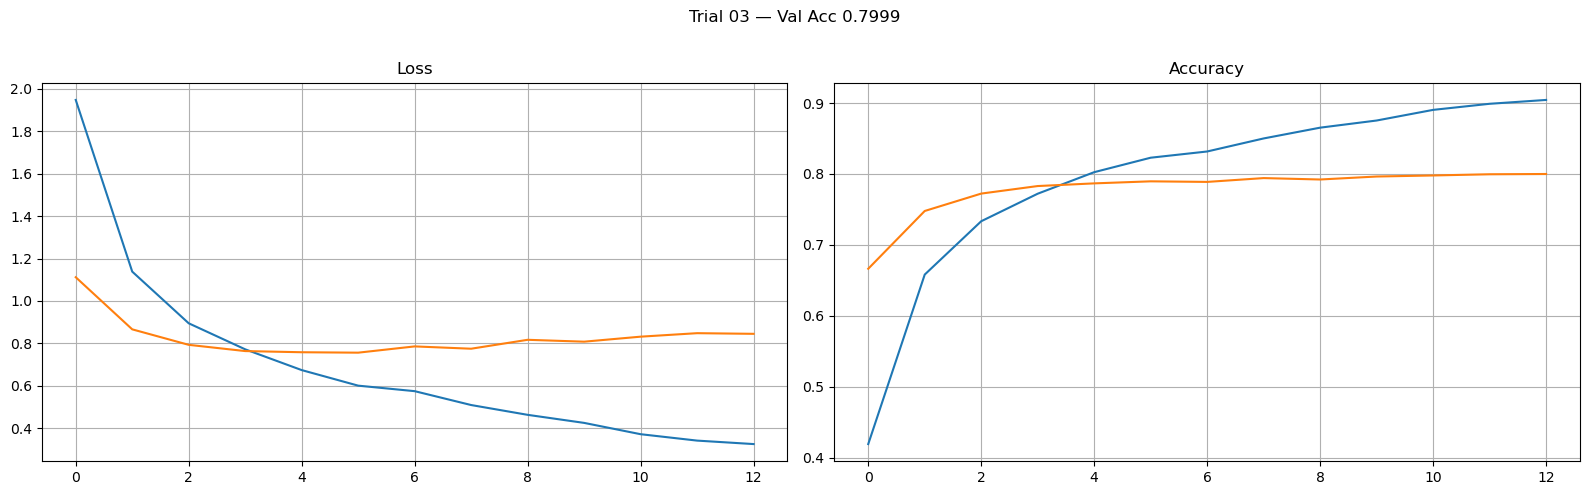

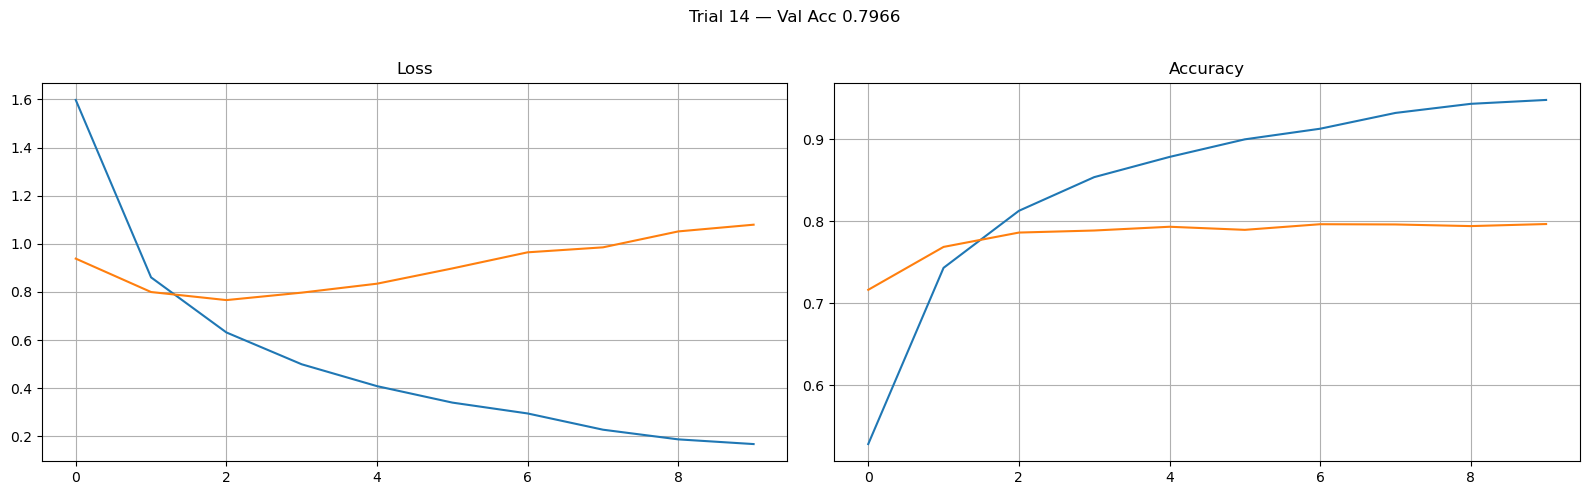

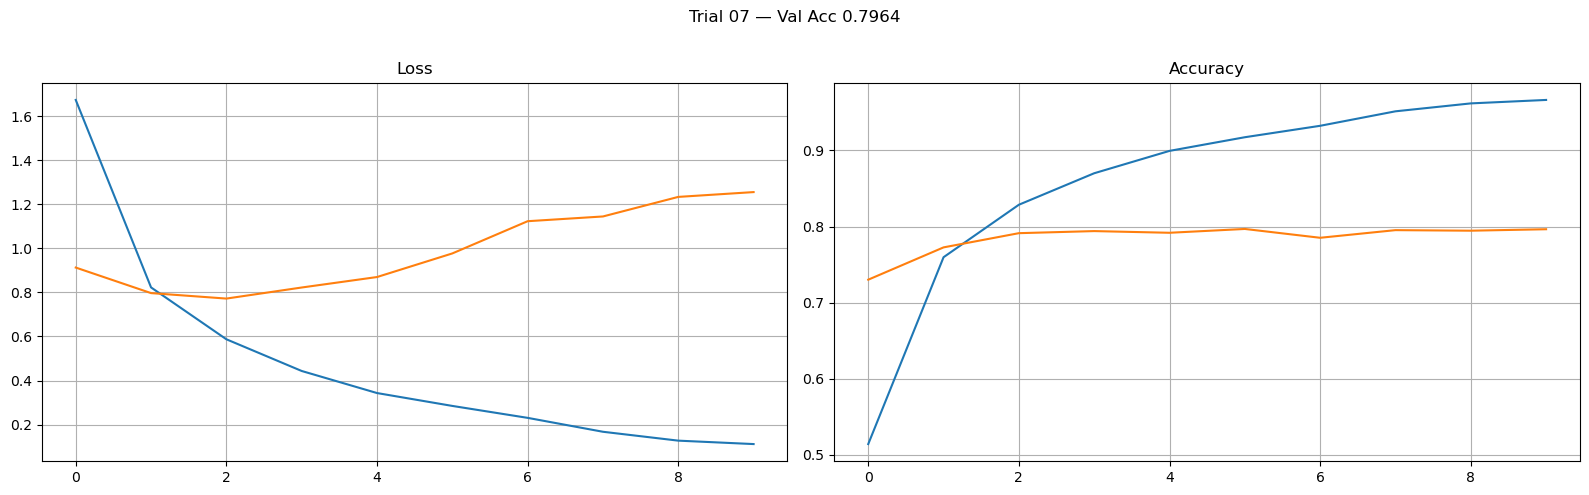

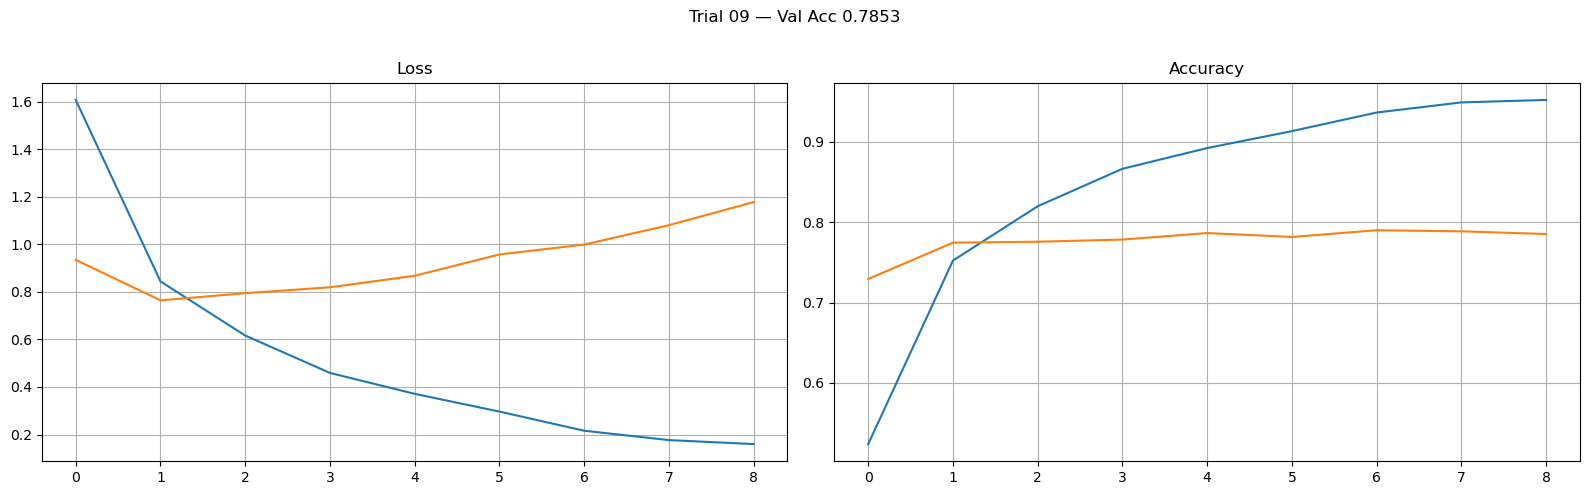

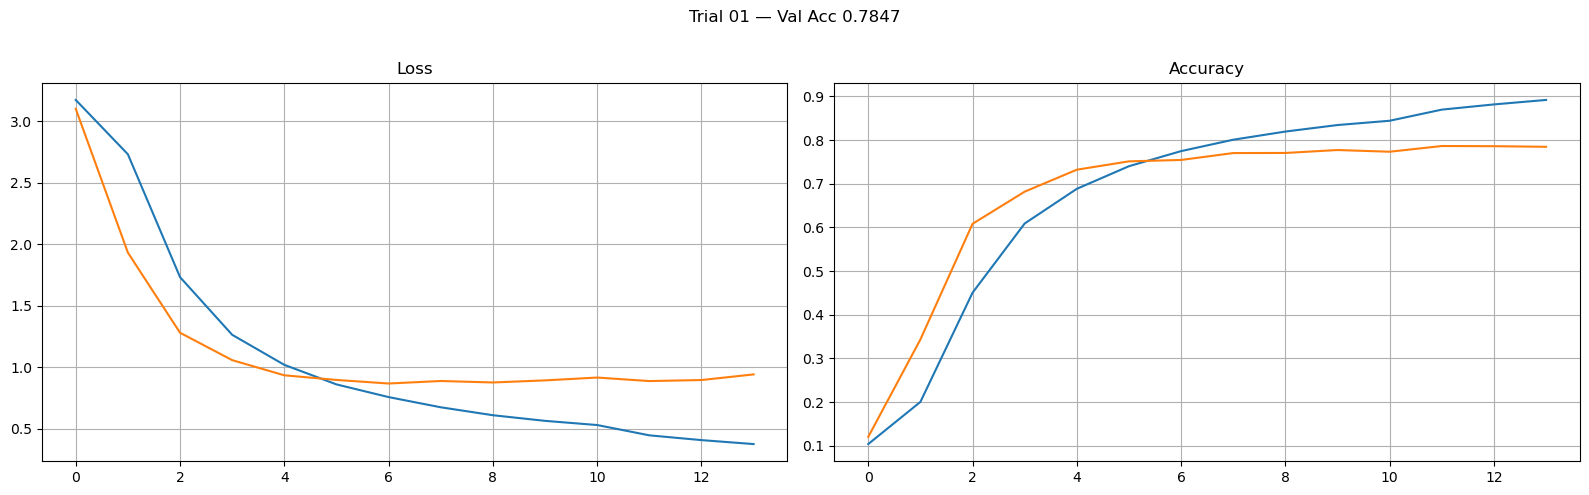

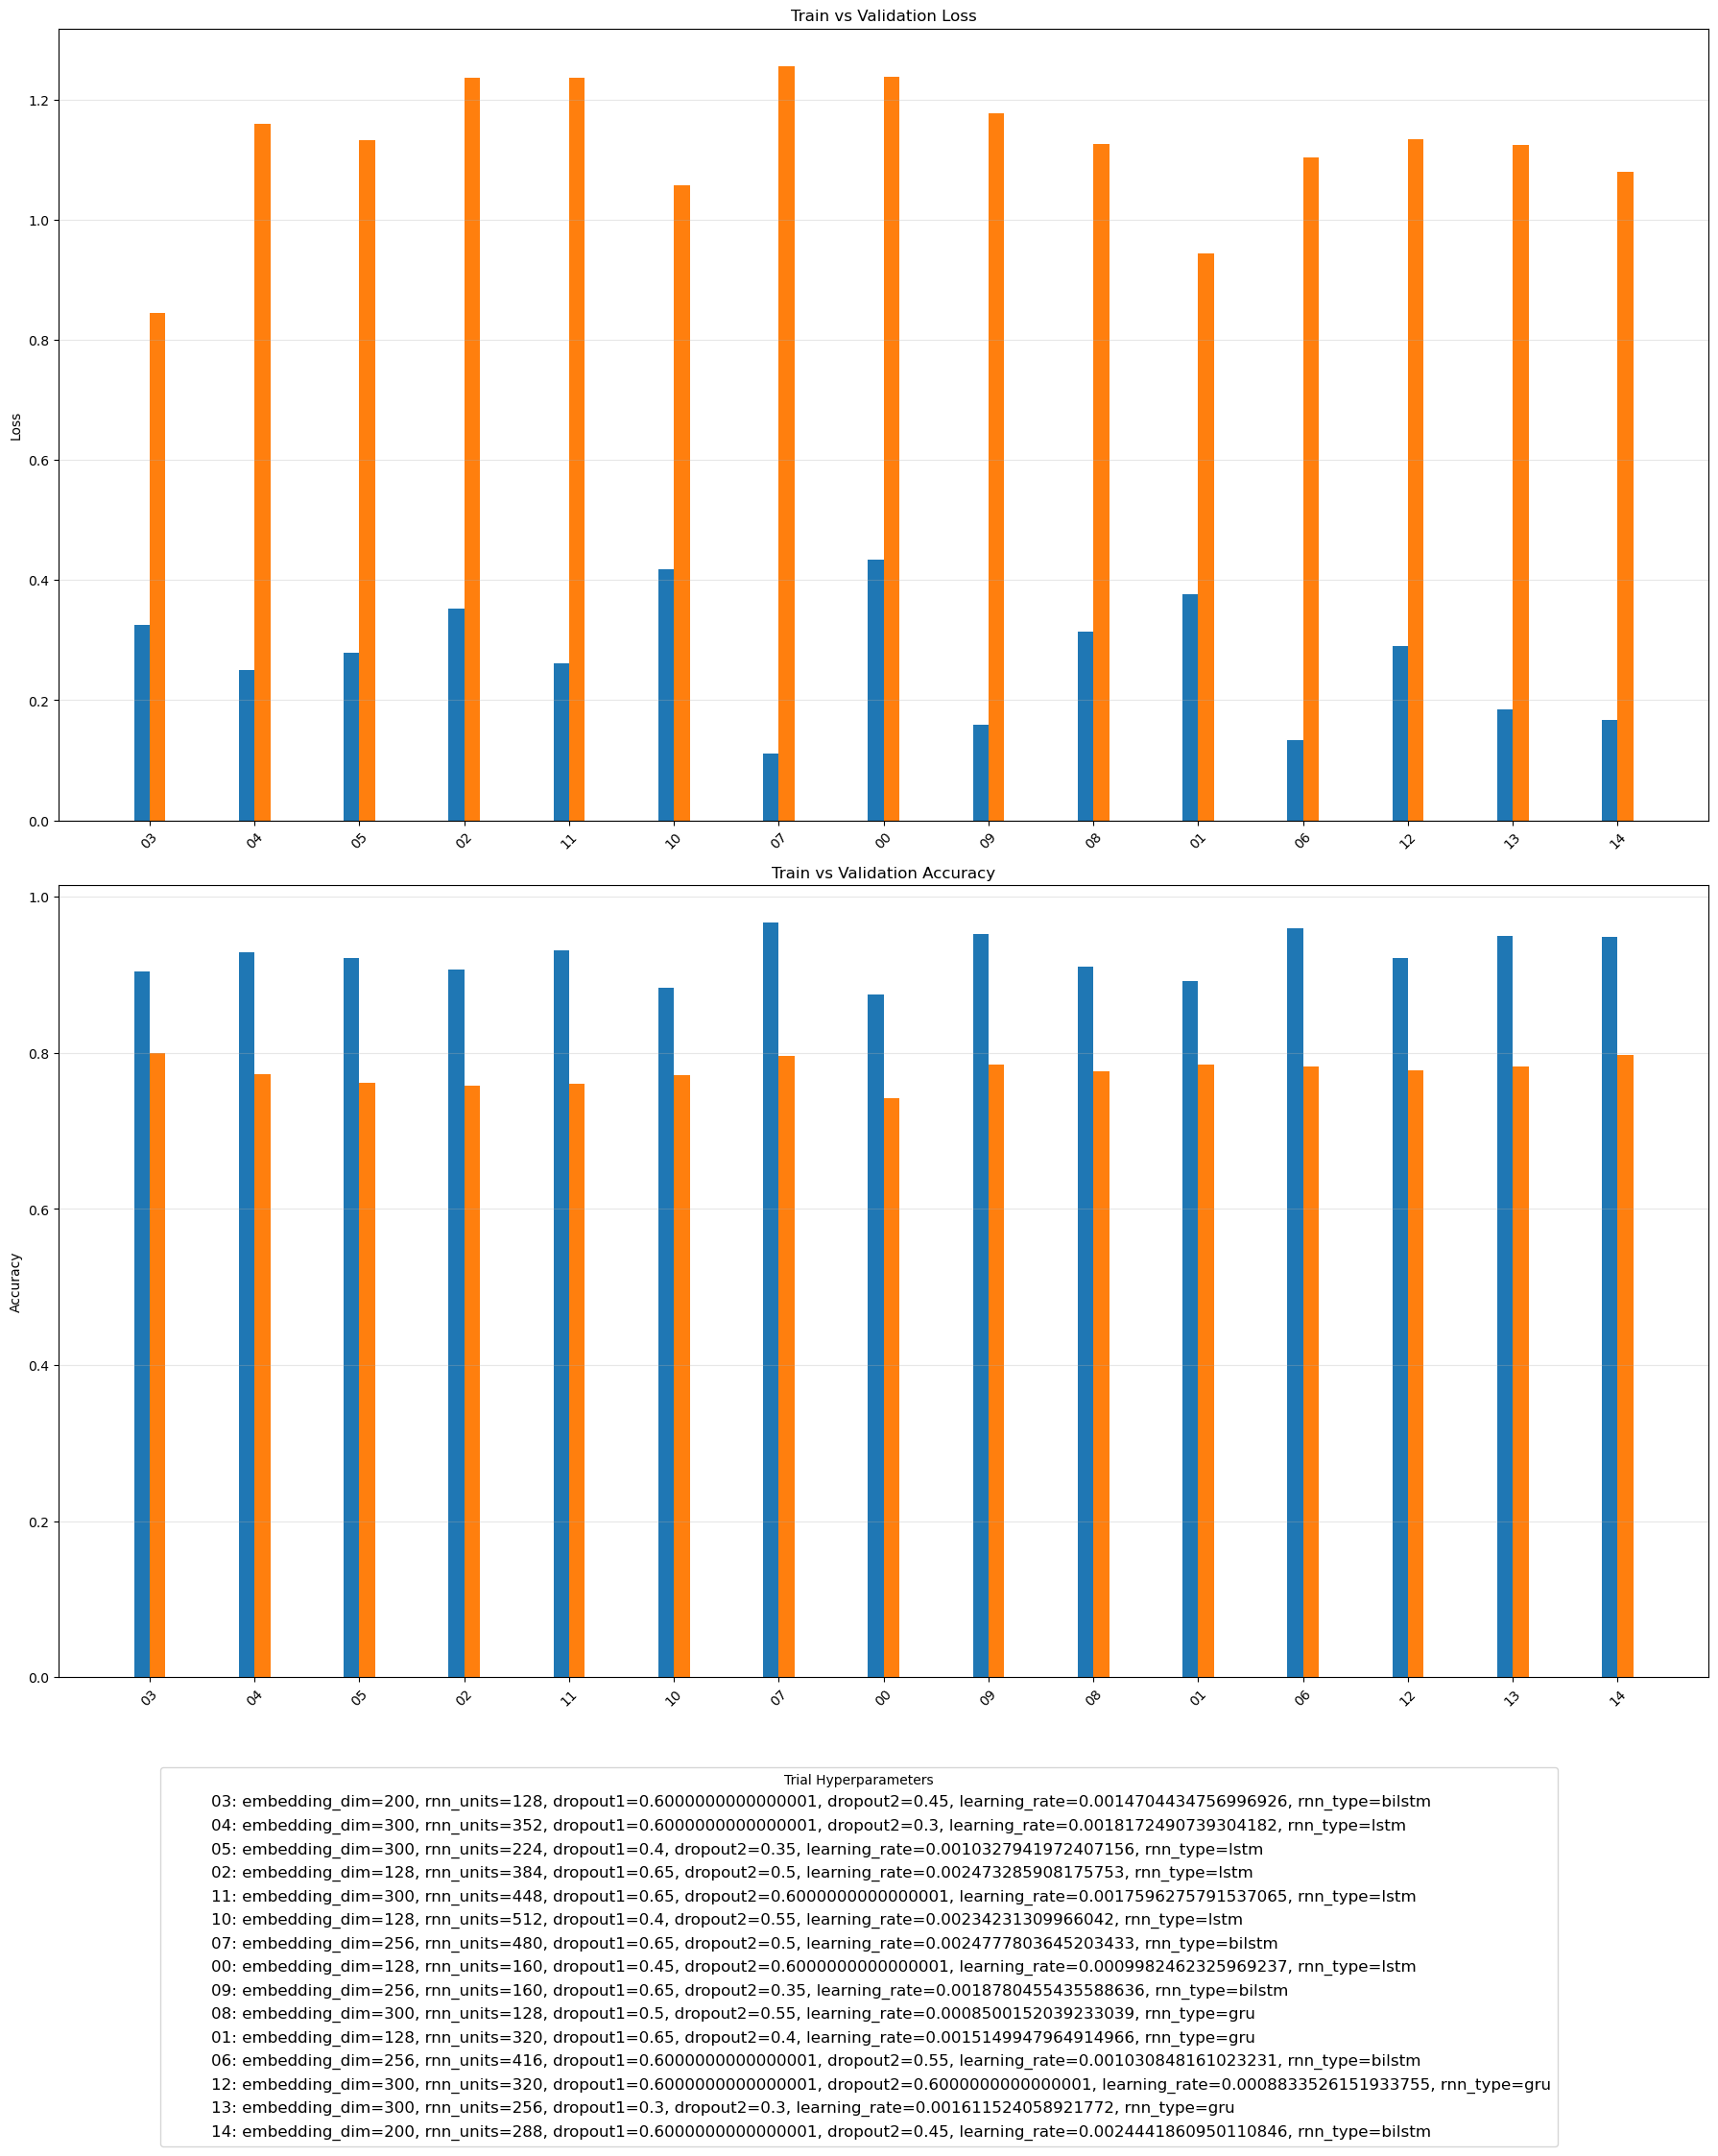

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# 1. Load all trial histories
# ==========================================================
def load_all_histories(tuner_dir):
    histories = {}
    tuner_project_dir = os.path.join(tuner_dir, "rakuten_fast")

    for trial_id in os.listdir(tuner_project_dir):
        history_path = os.path.join(tuner_project_dir, trial_id, "history.json")
        if os.path.exists(history_path):
            with open(history_path, "r") as f:
                histories[trial_id] = json.load(f)

    return histories


# ==========================================================
# Helper: Load hyperparameters for a trial
# ==========================================================
def load_hyperparameters(tuner_dir, trial_id):
    trial_json = os.path.join(tuner_dir, "rakuten_fast", trial_id, "trial.json")

    if os.path.exists(trial_json):
        with open(trial_json, "r") as f:
            trial_data = json.load(f)
        return trial_data["hyperparameters"]["values"]

    return {}  # fallback


# ==========================================================
# 2. Get the final val_accuracy of each trial
# ==========================================================
def get_top_trials(histories, top_k=5):
    trial_scores = []

    for trial_id, hist in histories.items():
        if "val_accuracy" in hist and len(hist["val_accuracy"]) > 0:
            trial_scores.append((trial_id, hist["val_accuracy"][-1]))

    trial_scores.sort(key=lambda x: x[1], reverse=True)
    return trial_scores[:top_k]


# ==========================================================
# 3. Plot train & validation accuracy for top trials
# ==========================================================
def plot_top_trials(histories, top_trials, tuner_dir="tuner_dir"):

    for trial_id, score in top_trials:
        hist = histories[trial_id]

        train_loss = hist.get("loss", [])
        val_loss = hist.get("val_loss", [])
        train_acc = hist.get("accuracy", [])
        val_acc = hist.get("val_accuracy", [])
        epochs = range(len(train_loss))

        # Load HPs
        hp_values = load_hyperparameters(tuner_dir, trial_id)

        important_keys = ["embedding_dim", "rnn_units", "dropout1",
                          "dropout2", "learning_rate", "rnn_type"]
        hyper_text = ", ".join(
            f"{k}={hp_values.get(k)}" for k in important_keys if k in hp_values
        )

        # === PLOT LOSS + ACCURACY ===
        fig, axs = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f"Trial {trial_id} — Val Acc {score:.4f}\n{hyper_text}",
                     fontsize=12)

        # Loss plot
        axs[0].plot(epochs, train_loss, label="Train Loss")
        axs[0].plot(epochs, val_loss, label="Validation Loss")
        axs[0].set_title("Loss")
        axs[0].grid(True)

        # Accuracy plot
        axs[1].plot(epochs, train_acc, label="Train Accuracy")
        axs[1].plot(epochs, val_acc, label="Validation Accuracy")
        axs[1].set_title("Accuracy")
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()


# ==========================================================
# 4. NEW — Bar Plot for Each Trial's Train & Val Loss
# ==========================================================
def plot_loss_acc_bar_chart(histories, tuner_dir="tuner_dir"):
    
    trial_ids = []
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    hp_texts = []

    for trial_id, hist in histories.items():
        trial_ids.append(trial_id)

        # FINAL epoch metrics
        train_losses.append(hist.get("loss", [None])[-1])
        val_losses.append(hist.get("val_loss", [None])[-1])
        train_accs.append(hist.get("accuracy", [None])[-1])
        val_accs.append(hist.get("val_accuracy", [None])[-1])

        # Load hyperparameters from correct path
        trial_json = os.path.join(tuner_dir, "rakuten_fast", "trial_"+trial_id, "trial.json")
        if os.path.exists(trial_json):
            with open(trial_json, "r") as f:
                trial_data = json.load(f)
                hp_data = trial_data.get("hyperparameters", {}).get("values", {})
        else:
            hp_data = {}

        # Select important hyperparameters
        important_keys = ["embedding_dim", "rnn_units", "dropout1", "dropout2", 
                          "learning_rate", "rnn_type"]
        hp_text = ", ".join(
            f"{k}={hp_data.get(k)}" for k in important_keys if k in hp_data
        )
        hp_texts.append(hp_text)

    x = np.arange(len(trial_ids))
    width = 0.15

    # -----------------------------
    # Create figure with two bar plots (side by side)
    # -----------------------------
    fig, axs = plt.subplots(2, 1, figsize=(18, 18))

    # LOSS
    axs[0].bar(x - width/2, train_losses, width, label="Train Loss")
    axs[0].bar(x + width/2, val_losses, width, label="Validation Loss")
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(trial_ids, rotation=45)
    axs[0].set_ylabel("Loss")
    axs[0].set_title("Train vs Validation Loss")
    axs[0].grid(axis='y', alpha=0.3)

    # ACCURACY
    axs[1].bar(x - width/2, train_accs, width, label="Train Accuracy")
    axs[1].bar(x + width/2, val_accs, width, label="Validation Accuracy")
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(trial_ids, rotation=45)
    axs[1].set_ylabel("Accuracy")
    axs[1].set_title("Train vs Validation Accuracy")
    axs[1].grid(axis='y', alpha=0.3)

    # -----------------------------
    # Legend with hyperparameters
    # -----------------------------
    trial_legend_labels = [f"{trial_ids[i]}: {hp_texts[i]}" for i in range(len(trial_ids))]
    dummy_lines = [plt.Line2D([0], [0], color='none') for _ in trial_legend_labels]

    fig.legend(
        dummy_lines,
        trial_legend_labels,
        title="Trial Hyperparameters",
        loc="lower center",
        ncol=1,
        fontsize=12,
        bbox_to_anchor=(0.5, -0.25)
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# 5. Run Everything
# ==========================================================
tuner_directory = "tuner_dir"

histories = load_all_histories(tuner_directory)
top_trials = get_top_trials(histories, top_k=5)

# plot top trial curves
plot_top_trials(histories, top_trials, tuner_dir=tuner_directory)

# plot bar chart for ALL trials
plot_loss_acc_bar_chart(histories)
